In [16]:
import numpy as np
import dataset_py
import ddpm
import torch
import matplotlib.pyplot as plt
import PD_ddpm
import FM
import PD_FM
import configs

In [ ]:
import importlib
importlib.reload(dataset_py)
importlib.reload(PD_FM)

In [ ]:
# data = np.load('./dataset/uniform2.npy')
data_perturbed = np.load('./dataset/uniform2_perturbed.npy')
# np.save('./dataset/uniform2_perturbed.npy', data_perturbed)

In [23]:
PD_FM_class = PD_FM.PDFlowMatching()
data_perturbed_tensor = torch.Tensor(data_perturbed).to(configs.FM_device)

inside_mask = PD_FM_class.check_inside(data_perturbed_tensor)
data_crop = data_perturbed_tensor[inside_mask]
data_crop_np = data_crop.cpu().numpy()

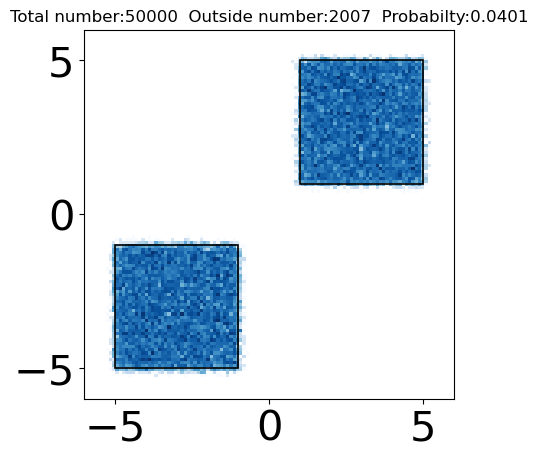

0

In [24]:
dataset_py.plot_scatter_hist(data_perturbed[:50000])

### FM trained on Q' (Train on truncated distribution)

In [ ]:
PD_FM_class = PD_FM.PDFlowMatching()
# data_tensor = torch.Tensor(data_perturbed).to(configs.FM_device)
PD_FM_class.train_vanilla(data_crop, epoches = 1000000, batch_size_N = 10000, save_every = 500000, lr = 1e-4, save_name = 'FM_trunc')

### PDFM trained on Q

In [ ]:
PD_FM_class = PD_FM.PDFlowMatching()

data_tensor = torch.Tensor(data_perturbed).to(PD_FM_class.device)
PD_FM_class.PDFMtrain(data_tensor, max_epoches_per_lambda=3000,batch_size_N = 10000, lr = 5e-6, init_ckpt_path='./saved_model/FM_Q_500000.pth', para_lambda_init = None, 
                      target_csrate = 0.995, PD_lr =500, tval = -1, update_pmodel_every = 1, OT = False, retrain_pmodel = False, patience = 100,
                      sample_trajectory=False,
                      p_model_batch_size=2000, save_name="PDFM_2uniform01",PD_lr_decay = 1) #OTFM_100000

### Visualize

In [ ]:
# ckpt = torch.load('./saved_model/FM_Q_500000.pth', weights_only=True)
ckpt = torch.load('./saved_model/FM_trunc_500000.pth', weights_only=True)
# ckpt = torch.load('./saved_model/PDFM_2uniform01/PDFM_2uniform01_18_41p46.pth', weights_only=True)
PD_FM_class.model.load_state_dict(ckpt)
res = PD_FM_class.sampler( 50000).cpu().numpy()


dataset_py.plot_scatter_hist(res, ref_samples=show_data, save_name = "FM_trunc", plotfig = True)